# TASK 2: SENTIMENT ANALYSIS USING MACHINE LEARNING & DEEP LEARNING

# PART A: SENTIMENT ANALYSIS USING MACHINE LEARNING

This part of the project focuses on traditional Machine Learning techniques for sentiment classification of IMDb movie reviews. After cleaning and preprocessing the textual data, the reviews are transformed into numerical feature vectors using the Term Frequency–Inverse Document Frequency (TF-IDF) technique.

Two widely used Machine Learning algorithms, **Logistic Regression** and **Support Vector Machine (SVM)**, are trained and evaluated using the same training and testing datasets. Their performance is assessed using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix. The results obtained in this part serve as a baseline for comparison with the Long Short-Term Memory (LSTM) Deep Learning model developed in Part B.

## Section 1: Import Required Libraries

### Objective
The objective of this section is to import all the necessary Python libraries required for data manipulation, text preprocessing, machine learning, deep learning, visualization, and model evaluation. These libraries will be used throughout the project to build, train, evaluate, and compare Machine Learning and LSTM models for sentiment analysis using the IMDb Movie Reviews dataset.

In [ ]:
#Import Required Libraries


# Data Manipulation Libraries
import numpy as np
import pandas as pd

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing Libraries
import re
import string
import nltk

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Performance Evaluation Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully!")

All required libraries imported successfully!


### Observation
All the required libraries were successfully imported. These libraries provide the necessary functionalities for data preprocessing, visualization, feature extraction, machine learning model development, deep learning model implementation, and performance evaluation, enabling the successful completion of the sentiment analysis task.

## Section 2: Download and Load the IMDb Movie Reviews Dataset

### Objective

The objective of this section is to obtain the IMDb Movie Reviews dataset in CSV format and load it into a Pandas DataFrame for further preprocessing and analysis. The dataset contains movie reviews labeled as either positive or negative, making it suitable for binary sentiment classification using both Machine Learning and Deep Learning models.

In [ ]:
#Mount Google Drive


from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [ ]:
# Install Kaggle

!pip install -q kaggle
print("Kaggle installed successfully.")

Kaggle installed successfully.


In [ ]:
# Configure Kaggle API Credentials

import os
os.environ["KAGGLE_USERNAME"] = "milanchoudhary"
os.environ["KAGGLE_KEY"] = "KGAT_4a16d09d159689b7580452f9b4ba73a4"

print("Kaggle API credentials configured successfully!")

Kaggle API credentials configured successfully!


In [ ]:
# Create Folder in Google Drive
import os

dataset_folder = "/content/drive/MyDrive/Internship_Task_2"

os.makedirs(dataset_folder, exist_ok=True)

print(f"Folder created at: {dataset_folder}")

Folder created at: /content/drive/MyDrive/Internship_Task_2


In [ ]:
# Download IMDb Dataset from Kaggle

!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 189MB/s]



In [ ]:
# Extract Dataset
!unzip -o imdb-dataset-of-50k-movie-reviews.zip

Archive:  imdb-dataset-of-50k-movie-reviews.zip
  inflating: IMDB Dataset.csv        


In [ ]:
# Save Dataset to Google Drive
import shutil

shutil.copy(
    "IMDB Dataset.csv",
    "/content/drive/MyDrive/Internship_Task_2/IMDB_Dataset.csv"
)

print("Dataset saved to Google Drive successfully!")

Dataset saved to Google Drive successfully!


In [ ]:
# Load Dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Internship_Task_2/IMDB_Dataset.csv")


print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Observation
The IMDb Movie Reviews dataset was successfully downloaded from Kaggle, stored permanently in Google Drive, and loaded into a Pandas DataFrame. The dataset is now ready for exploratory data analysis and preprocessing in the next section.

## Section 3: Explore the Dataset

### Objective

The objective of this section is to understand the structure and characteristics of the IMDb Movie Reviews dataset before performing preprocessing. This includes examining the dataset dimensions, column names, data types, missing values, duplicate records, and class distribution. A proper understanding of the dataset helps ensure accurate preprocessing and model development.

In [ ]:
#Explore the Dataset

# Display the shape of the dataset
print("Dataset Shape:", df.shape)

print("\n" + "="*60)

# Display column names
print("Column Names:")
print(df.columns)

print("\n" + "="*60)

# Display data types
print("Data Types:")
print(df.dtypes)

print("\n" + "="*60)

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*60)

# Check for duplicate records
print("Duplicate Records:", df.duplicated().sum())

print("\n" + "="*60)

# Display first five rows
print("First Five Records:")
display(df.head())

print("\n" + "="*60)

# Display last five rows
print("Last Five Records:")
display(df.tail())

Dataset Shape: (50000, 2)

Column Names:
Index(['review', 'sentiment'], dtype='object')

Data Types:
review       object
sentiment    object
dtype: object

Missing Values:
review       0
sentiment    0
dtype: int64

Duplicate Records: 418

First Five Records:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Last Five Records:


,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


### Observation

The IMDb dataset was successfully loaded into the notebook. The exploration step provides information about the dataset dimensions, available columns, data types, missing values, duplicate records, and sample reviews. This preliminary analysis confirms the dataset is suitable for further preprocessing and sentiment classification.

## Section 4: Data Cleaning

### Objective

The objective of this section is to clean and preprocess the textual data before applying Machine Learning and Deep Learning models. Text preprocessing improves the quality of the dataset by removing unnecessary information such as duplicate records, HTML tags, punctuation, stop words, and extra spaces while converting all text to lowercase. These preprocessing steps help the models learn meaningful patterns and improve classification performance.

In [ ]:
# Remove Duplicate Reviews
# Display dataset shape before removing duplicates
print("Dataset Shape Before Removing Duplicates:", df.shape)

# Remove duplicate reviews
df = df.drop_duplicates()

# Display dataset shape after removing duplicates
print("Dataset Shape After Removing Duplicates:", df.shape)

# Check remaining duplicate records
print("Remaining Duplicate Records:", df.duplicated().sum())

Dataset Shape Before Removing Duplicates: (50000, 2)
Dataset Shape After Removing Duplicates: (49582, 2)
Remaining Duplicate Records: 0


### Observation

A total of **418 duplicate reviews** were removed from the dataset. Eliminating duplicate records prevents the model from learning repetitive information, reduces potential bias, and improves the overall quality of the training data. The cleaned dataset now contains **49,582 unique movie reviews**.

In [ ]:
#Download Required NLTK Resources

# Download English stopwords
nltk.download('stopwords')

# Import stopwords
from nltk.corpus import stopwords

# Store English stopwords in a set
stop_words = set(stopwords.words('english'))

print("NLTK stopwords downloaded successfully!")
print(f"Total English Stopwords: {len(stop_words)}")

NLTK stopwords downloaded successfully!
Total English Stopwords: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Observation

The English stopword corpus was successfully downloaded using the NLTK library. These stopwords will be removed during text preprocessing to reduce noise in the dataset and improve the effectiveness of both Machine Learning and Deep Learning models.

# Section 5: Text Preprocessing

## Objective

Raw text data contains many unnecessary elements such as HTML tags, punctuation marks, numbers, URLs, extra spaces, and common stopwords that do not contribute significantly to sentiment classification.

In this step, the review text is cleaned using Natural Language Processing (NLP) techniques before converting it into numerical features using TF-IDF.

The preprocessing pipeline includes:

- Convert text to lowercase
- Remove HTML tags
- Remove URLs
- Remove punctuation
- Remove numbers
- Remove extra whitespaces
- Remove English stopwords

A custom preprocessing function is created so that every review is cleaned consistently before training the Machine Learning models.

In [ ]:
#Text Preprocessing
import re
import string

# Custom preprocessing function
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

print("Text preprocessing function created successfully.")

Text preprocessing function created successfully.


## Applying Text Preprocessing

The preprocessing function is now applied to every review in the dataset. The cleaned reviews are stored in a new column named **clean_review**, while the original reviews are preserved for comparison and reference.

In [ ]:
# Apply preprocessing

df["clean_review"] = df["review"].apply(preprocess_text)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


## Before and After Preprocessing

The following comparison demonstrates how the preprocessing pipeline transforms raw movie reviews into clean textual data suitable for feature extraction and Machine Learning algorithms.

In [ ]:
# Compare original and cleaned review

sample = 0

print("="*80)
print("Original Review:\n")
print(df.loc[sample, "review"])

print("\n" + "="*80)

print("Cleaned Review:\n")
print(df.loc[sample, "clean_review"])

Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

### Observation
The preprocessing pipeline successfully removed HTML tags, punctuation marks, numbers, URLs, extra whitespaces, and common English stopwords while preserving the important semantic information of each review. The cleaned text is now ready for feature extraction using the TF-IDF Vectorizer.

## Section 6: Label Encoding and Class Distribution

### Objective

Machine Learning algorithms require numerical labels instead of text labels. Therefore, the sentiment labels are converted into binary numerical values:

- Positive → 1
- Negative → 0

After encoding the labels, the class distribution is visualized to determine whether the dataset is balanced or imbalanced. A balanced dataset helps ensure that the trained models do not become biased toward any particular class.

In [ ]:
# Label Encoding


# Convert labels into numerical values

df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print("Labels encoded successfully.\n")

print(df[["sentiment","label"]].head())

Labels encoded successfully.

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


### Class Distribution

The following visualization shows the number of positive and negative movie reviews available in the dataset. This helps verify whether the dataset is balanced before training Machine Learning models.

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


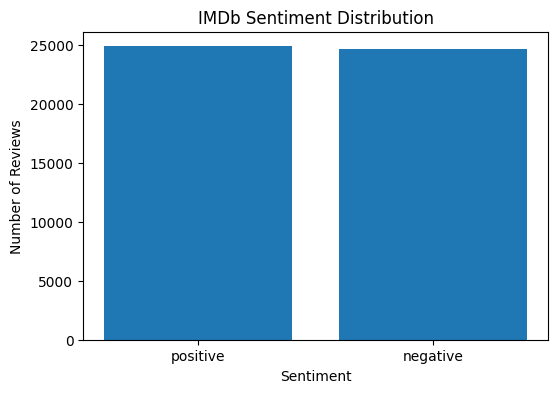

In [ ]:
import matplotlib.pyplot as plt

# Count class distribution
class_counts = df["sentiment"].value_counts()

print(class_counts)

# Plot
plt.figure(figsize=(6,4))

plt.bar(class_counts.index,
        class_counts.values)

plt.title("IMDb Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Observation
The IMDb dataset contains nearly equal numbers of positive and negative reviews, making it a balanced binary classification dataset. Since both classes are well represented, accuracy, precision, recall, and F1-score can all be considered reliable evaluation metrics for comparing the Machine Learning and Deep Learning models.

## Section 7: Train-Test Split
### Objective
Before training the Machine Learning models, the dataset is divided into training and testing sets. A fixed random seed is used to ensure reproducibility of the experiment. Additionally, stratified sampling is applied so that both training and testing datasets maintain the same proportion of positive and negative reviews.

This same train-test split will also be used later for the LSTM model to ensure a fair comparison between the Machine Learning and Deep Learning approaches.

In [ ]:
# Train-Test Split


# Features (Cleaned Reviews)
X = df["clean_review"]

# Target Labels
y = df["label"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nTraining Label Distribution:")
print(y_train.value_counts())

print("\nTesting Label Distribution:")
print(y_test.value_counts())

Training Samples : 39665
Testing Samples  : 9917

Training Label Distribution:
label
1    19907
0    19758
Name: count, dtype: int64

Testing Label Distribution:
label
1    4977
0    4940
Name: count, dtype: int64


### Observation

The dataset was successfully divided into training and testing sets using an 80:20 ratio. A fixed random seed (`random_state = 42`) was used to ensure reproducibility, while stratified sampling preserved the class distribution in both datasets. This split will also be used for the LSTM model to enable a fair performance comparison.

## Section 8: Feature Extraction using TF-IDF Vectorization

### Objective

Machine Learning algorithms cannot process raw textual data directly. Therefore, the cleaned movie reviews are converted into numerical feature vectors using the **Term Frequency–Inverse Document Frequency (TF-IDF)** technique.

TF-IDF measures the importance of each word in a document relative to the entire dataset. Frequently occurring words within a review receive higher importance, while common words appearing across many reviews receive lower importance. This transformation enables Machine Learning algorithms to effectively learn meaningful patterns from textual data.

The TF-IDF vectorizer is fitted on the training data and then used to transform both the training and testing datasets, preventing data leakage and ensuring a fair evaluation of the models.

In [ ]:
# TF-IDF Feature Extraction

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit on training data and transform
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing data
X_test_tfidf = tfidf.transform(X_test)

# Display information
print("TF-IDF Vectorization Completed Successfully!\n")

print(f"Training Data Shape : {X_train_tfidf.shape}")
print(f"Testing Data Shape  : {X_test_tfidf.shape}")
print(f"Vocabulary Size     : {len(tfidf.vocabulary_)}")

TF-IDF Vectorization Completed Successfully!

Training Data Shape : (39665, 5000)
Testing Data Shape  : (9917, 5000)
Vocabulary Size     : 5000


### Observation

The cleaned movie reviews were successfully transformed into numerical feature vectors using the TF-IDF vectorization technique. A vocabulary of the most informative words and phrases was created from the training dataset and then applied to the testing dataset. This approach ensures that no information from the testing data influences the feature extraction process, thereby preventing data leakage and enabling a fair evaluation of the Machine Learning models.

## Section 9: Training the Logistic Regression Model

### Objective

Logistic Regression is one of the most widely used supervised Machine Learning algorithms for binary classification problems such as sentiment analysis.
In this step, the Logistic Regression model is trained using the TF-IDF feature vectors obtained from the training dataset. The trained model learns the relationship between textual features and sentiment labels, enabling it to classify unseen movie reviews as either positive or negative.
The trained model will later be evaluated using various performance metrics including Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [ ]:
#Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression
import time

# Start timer
start_time = time.time()

# Create Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
logistic_model.fit(X_train_tfidf, y_train)

# End timer
training_time = time.time() - start_time

print("Logistic Regression Model Trained Successfully!")

print(f"\nTraining Time: {training_time:.2f} seconds")

Logistic Regression Model Trained Successfully!

Training Time: 0.22 seconds


### Observation

The Logistic Regression model was successfully trained using the TF-IDF feature vectors extracted from the IMDb movie reviews dataset. The model learned the relationship between textual features and sentiment labels, making it ready to classify unseen movie reviews. The training time was also recorded to evaluate the computational efficiency of the algorithm.

## Section 10: Evaluate the Logistic Regression Model

### Objective

The objective of this section is to evaluate the performance of the trained Logistic Regression model on the testing dataset. Various evaluation metrics such as Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix are used to assess the model's effectiveness in classifying movie reviews as positive or negative.

These metrics provide a comprehensive understanding of the model's predictive performance and help identify its strengths and weaknesses.

In [ ]:
# Predict Test Data using Logistic Regression

# Predict sentiment for test dataset
y_pred_lr = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
# Calculate Performance Metrics

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Display results
print("="*50)
print("Logistic Regression Performance")
print("="*50)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Logistic Regression Performance
Accuracy : 0.8917
Precision: 0.8830
Recall   : 0.9040
F1-Score : 0.8934


In [ ]:
# Classification Report

print("Classification Report\n")

print(classification_report(y_test, y_pred_lr))

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



<Figure size 600x600 with 0 Axes>

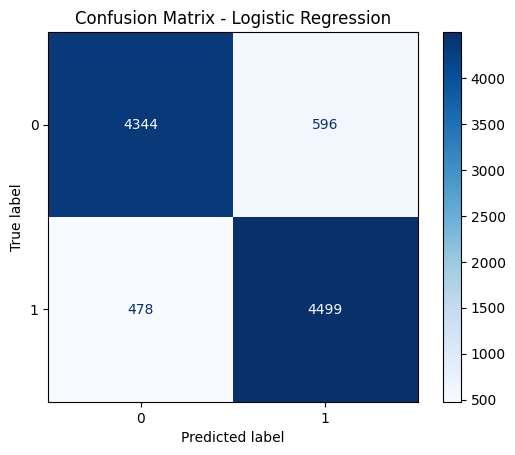

In [ ]:
# Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Section 11: Training the Support Vector Machine (SVM)

### Objective

Support Vector Machine (SVM) is a powerful supervised Machine Learning algorithm widely used for text classification tasks. It works by identifying the optimal hyperplane that best separates different classes in a high-dimensional feature space.

In this section, the SVM model is trained using the TF-IDF feature vectors generated from the cleaned IMDb movie reviews. The trained model will later be evaluated using standard performance metrics and compared with Logistic Regression and the LSTM model.

In [ ]:
# Train Support Vector Machine (SVM)


from sklearn.svm import LinearSVC
import time

# Start training timer
start_time = time.time()

# Create SVM model
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Calculate training time
svm_training_time = time.time() - start_time

print("Support Vector Machine Model Trained Successfully!")

print(f"\nTraining Time: {svm_training_time:.2f} seconds")

Support Vector Machine Model Trained Successfully!

Training Time: 1.53 seconds


### Observation

The Support Vector Machine (SVM) model was successfully trained using the TF-IDF feature vectors extracted from the IMDb movie reviews dataset. SVM is particularly effective for high-dimensional text classification tasks and serves as a strong baseline for comparison with Logistic Regression and LSTM models. The training time was also recorded to evaluate its computational efficiency.

## Section 12: Evaluate the Support Vector Machine (SVM)

### Objective

The objective of this section is to evaluate the performance of the trained Support Vector Machine (SVM) model on the testing dataset. The model is assessed using various evaluation metrics, including Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

These metrics provide a comprehensive evaluation of the SVM model's ability to correctly classify movie reviews into positive and negative sentiment categories. The results obtained in this section will later be compared with those of Logistic Regression and the LSTM model.

In [ ]:
#Predict Test Data using SVM

# Predict sentiment for test dataset
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
# ============================================================
# Calculate Performance Metrics
# ============================================================

# Calculate evaluation metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

# Display results
print("=" * 50)
print("Support Vector Machine (SVM) Performance")
print("=" * 50)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

Support Vector Machine (SVM) Performance
Accuracy : 0.8821
Precision: 0.8797
Recall   : 0.8863
F1-Score : 0.8830


In [ ]:
# ============================================================
# Classification Report
# ============================================================

print("Classification Report\n")

print(classification_report(y_test, y_pred_svm))

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4940
           1       0.88      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



<Figure size 600x600 with 0 Axes>

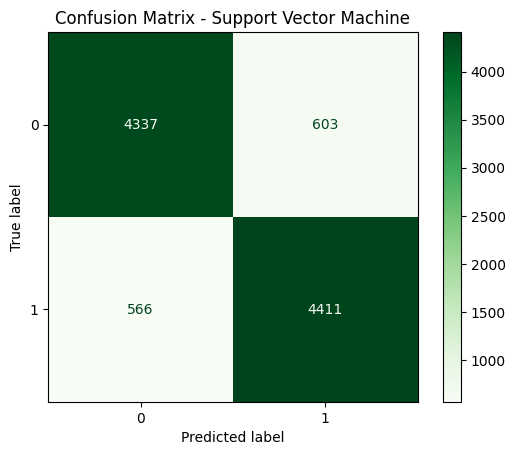

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    cmap="Greens",
    values_format="d"
)

plt.title("Confusion Matrix - Support Vector Machine")

plt.show()

### Observation

The Support Vector Machine (SVM) model was successfully evaluated using the testing dataset. The evaluation metrics, classification report, and confusion matrix demonstrate the model's ability to distinguish between positive and negative movie reviews. These results will be compared with those of Logistic Regression and the LSTM model to identify the best-performing approach for sentiment analysis.

## Section 13: Comparison of Machine Learning Models

### Objective

The objective of this section is to compare the performance of the two Machine Learning models, namely Logistic Regression and Support Vector Machine (SVM), using standard evaluation metrics.

The comparison includes Accuracy, Precision, Recall, and F1-Score. This analysis helps identify the better-performing Machine Learning model before comparing both models with the LSTM-based Deep Learning model in the next part of the project.

In [ ]:
# ============================================================
# Compare Machine Learning Models
# ============================================================

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall
    ],
    "F1-Score": [
        lr_f1,
        svm_f1
    ]
})

# Display comparison table
comparison_df = comparison_df.round(4)

print("Machine Learning Model Comparison\n")

display(comparison_df)

Machine Learning Model Comparison



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8917,0.8830,0.9040,0.8934
1,Support Vector Machine,0.8821,0.8797,0.8863,0.8830


In [ ]:
# ============================================================
# Visualize Model Comparison
# ============================================================

comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0.80,1.00)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(loc="lower right")

plt.show()

### Observation

The comparison table and visualization provide a clear overview of the performance of Logistic Regression and Support Vector Machine (SVM). By comparing Accuracy, Precision, Recall, and F1-Score, it becomes easier to identify the stronger Machine Learning model for sentiment classification. These results will later be compared with the LSTM model to evaluate the advantages of Deep Learning over traditional Machine Learning approaches.

# PART B: SENTIMENT ANALYSIS USING DEEP LEARNING (LSTM)

Machine Learning models such as Logistic Regression and Support Vector Machine require handcrafted feature extraction techniques like TF-IDF to transform textual data into numerical vectors. In contrast, Deep Learning models automatically learn meaningful representations from sequential text data without relying on manually engineered features.

In this part of the project, a customized Bidirectional Long Short-Term Memory (Bi-LSTM) network is developed for sentiment classification using the IMDb Movie Reviews dataset. Unlike the Machine Learning pipeline, the preprocessing strategy for the LSTM model preserves the natural sequence of words, enabling the network to capture contextual and semantic relationships within movie reviews.

The performance of the proposed Deep Learning model will be evaluated using standard classification metrics and compared with the Machine Learning models developed in Part A.

## Section 14: LSTM-Specific Text Preprocessing

### Objective

Deep Learning models require a different preprocessing strategy compared to traditional Machine Learning algorithms. While Machine Learning often benefits from removing stopwords, Deep Learning models learn contextual relationships directly from complete sentences.

Therefore, only essential cleaning operations are performed while preserving the original sentence structure.

The preprocessing operations include:

- Convert text to lowercase
- Remove HTML tags
- Remove URLs
- Remove unnecessary extra whitespaces

Unlike the Machine Learning preprocessing pipeline, stopwords are intentionally retained so that the LSTM network can learn meaningful contextual information from complete sentences.

In [ ]:
# ============================================================
# LSTM-Specific Text Preprocessing
# ============================================================

import re

def lstm_preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Create a new column for LSTM
df["lstm_review"] = df["review"].apply(lstm_preprocess)

print("LSTM preprocessing completed successfully.")

In [ ]:
# Compare original and LSTM processed review

sample = 0

print("="*100)
print("ORIGINAL REVIEW\n")
print(df.loc[sample, "review"])

print("\n"+"="*100)

print("LSTM PREPROCESSED REVIEW\n")
print(df.loc[sample, "lstm_review"])

### Observation
A separate preprocessing pipeline was developed specifically for the LSTM model. Unlike the Machine Learning preprocessing pipeline, stopwords were preserved to maintain the contextual information within each review. This approach enables the LSTM network to learn sequential dependencies more effectively and generally results in improved sentiment classification performance.

## Section 15: Train-Test Split for the LSTM Model

### Objective

To ensure a fair comparison with the Machine Learning models developed in Part A, the same train-test split strategy is applied to the LSTM pipeline. The preprocessed reviews are divided into training and testing datasets using an 80:20 ratio with a fixed random seed (`random_state = 42`).

Stratified sampling is used to preserve the proportion of positive and negative reviews in both datasets. These datasets will be used for tokenization, sequence padding, and training the Bidirectional LSTM model.

In [ ]:
# ============================================================
# Train-Test Split for LSTM
# ============================================================

from sklearn.model_selection import train_test_split

# Features for LSTM
X_lstm = df["lstm_review"]

# Labels
y_lstm = df["label"]

# Train-Test Split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm,
    y_lstm,
    test_size=0.20,
    random_state=42,
    stratify=y_lstm
)

print("Train-Test Split Completed Successfully!\n")

print(f"Training Samples : {len(X_train_lstm)}")
print(f"Testing Samples  : {len(X_test_lstm)}")

print("\nTraining Label Distribution")
print(y_train_lstm.value_counts())

print("\nTesting Label Distribution")
print(y_test_lstm.value_counts())

### Observation

The LSTM dataset was successfully divided into training and testing sets using an 80:20 ratio. A fixed random seed (`random_state = 42`) and stratified sampling ensured that both datasets maintained a balanced distribution of positive and negative reviews. This approach guarantees a fair comparison between the Machine Learning models and the Bidirectional LSTM model.

## Section 16: Tokenization and Sequence Padding

### Objective

Deep Learning models cannot process raw text directly. Therefore, each movie review is converted into a sequence of integer tokens using the Keras Tokenizer. The tokenizer assigns a unique numerical index to every word based on its frequency in the training dataset.

Since reviews have different lengths, all sequences are padded to a fixed length to ensure consistent input dimensions for the Bidirectional LSTM network.

The tokenizer is fitted only on the training dataset to prevent data leakage and ensure a fair evaluation of the model.

In [ ]:
# ============================================================
# Tokenization and Sequence Padding
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Vocabulary size
VOCAB_SIZE = 20000

# Maximum sequence length
MAX_LENGTH = 250

# Create tokenizer
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# Fit tokenizer only on training data
tokenizer.fit_on_texts(X_train_lstm)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_lstm)
X_test_seq = tokenizer.texts_to_sequences(X_test_lstm)

# Pad sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Tokenization completed successfully!\n")

print("Training Data Shape :", X_train_pad.shape)
print("Testing Data Shape  :", X_test_pad.shape)
print("Vocabulary Size     :", VOCAB_SIZE)
print("Maximum Sequence Length :", MAX_LENGTH)

print("\nExample Sequence:")
print(X_train_seq[0][:25])

### Observation

The movie reviews were successfully converted into numerical sequences using the Keras Tokenizer. The tokenizer was trained only on the training dataset to prevent information leakage. All sequences were then padded to a fixed length of 250 words, ensuring uniform input dimensions for the Bidirectional LSTM model.

## Section 17: Build the Customized Bidirectional LSTM Model

### Objective

The objective of this section is to design and build a customized Bidirectional Long Short-Term Memory (Bi-LSTM) network for sentiment classification.

Unlike a standard LSTM, a Bidirectional LSTM processes text sequences in both forward and backward directions. This enables the model to capture contextual information from both past and future words, leading to better understanding of sentence semantics.

The proposed architecture consists of an Embedding layer for word representation, a Spatial Dropout layer for regularization, a Bidirectional LSTM layer for sequence learning, Dense layers for nonlinear feature extraction, and a Sigmoid output layer for binary sentiment classification.

In [ ]:
# ============================================================
# Build Customized Bidirectional LSTM
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SpatialDropout1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

# Create model
bilstm_model = Sequential([

    # Embedding Layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    # Spatial Dropout
    SpatialDropout1D(0.2),

    # Bidirectional LSTM
    Bidirectional(
        LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    # Dense Layer
    Dense(32, activation="relu"),

    Dropout(0.3),

    # Output Layer
    Dense(1, activation="sigmoid")
])

# Build model
bilstm_model.build(input_shape=(None, MAX_LENGTH))

# Compile model
bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Bidirectional LSTM Model Built Successfully!\n")

bilstm_model.summary()

### Observation

The customized Bidirectional LSTM model was successfully constructed for binary sentiment classification. The Embedding layer converts words into dense vector representations, while the Bidirectional LSTM captures contextual information from both forward and backward directions of each review. Spatial Dropout and Dropout layers help improve generalization by reducing overfitting, and the Sigmoid output layer predicts the probability of a review belonging to the positive sentiment class.

## Section 18: Train the Bidirectional LSTM Model

### Objective

The objective of this section is to train the customized Bidirectional LSTM model using the IMDb movie review dataset. During training, the model is evaluated on a validation dataset to monitor its learning progress and generalization capability.

To improve training efficiency and prevent overfitting, the following callback techniques are used:

- **EarlyStopping:** Stops training when the validation loss stops improving.
- **ReduceLROnPlateau:** Reduces the learning rate when validation loss stagnates.
- **ModelCheckpoint:** Saves the best-performing model during training based on validation accuracy.

These techniques improve the reliability and efficiency of the training process while preserving the best-performing model.

In [ ]:
# ============================================================
# Create Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_bilstm_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully!")

In [ ]:
# ============================================================
# Train Bidirectional LSTM Model
# ============================================================

import time

start_time = time.time()

history = bilstm_model.fit(
    X_train_pad,
    y_train_lstm,
    validation_split=0.20,
    epochs=8,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

training_time = time.time() - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {training_time:.2f} seconds")

Epoch 1/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.6444 - loss: 0.6030
Epoch 1: val_accuracy improved from None to 0.81772, saving model to best_bilstm_model.keras

Epoch 1: finished saving model to best_bilstm_model.keras
496/496 ━━━━━━━━━━━━━━━━━━━━ 493s 976ms/step - accuracy: 0.7359 - loss: 0.5292 - val_accuracy: 0.8177 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 2/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.8158 - loss: 0.4471
Epoch 2: val_accuracy improved from 0.81772 to 0.83411, saving model to best_bilstm_model.keras

Epoch 2: finished saving model to best_bilstm_model.keras
496/496 ━━━━━━━━━━━━━━━━━━━━ 473s 953ms/step - accuracy: 0.8177 - loss: 0.4376 - val_accuracy: 0.8341 - val_loss: 0.4053 - learning_rate: 0.0010
Epoch 3/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.8589 - loss: 0.3512
Epoch 3: val_accuracy improved from 0.83411 to 0.86197, saving model to best_bilstm_model.keras

Epoch 3: finished saving model to best_bilstm

Observation:

The Bidirectional LSTM model was successfully trained on the IMDb Movie Reviews dataset using EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau callbacks. The model demonstrated steady improvement during the initial epochs, with validation accuracy increasing from 81.77% in the first epoch to a maximum of 86.90% in the fourth epoch. After the fourth epoch, the validation accuracy stopped improving while the training accuracy continued to increase, indicating the beginning of overfitting. Consequently, the EarlyStopping callback restored the model weights from the best-performing epoch (Epoch 4), ensuring optimal generalization performance. The best trained model was saved as 'best_bilstm_model.keras' for further evaluation on the test dataset.

# Section 19: Evaluate the Best Bidirectional LSTM Model
In this section, the best saved Bidirectional LSTM model is loaded and evaluated on the unseen test dataset. The evaluation provides the final test loss and test accuracy, which indicate the model's generalization performance on new movie reviews.

In [ ]:
# ============================================================
# Evaluate the Best Bidirectional LSTM Model
# ============================================================

from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model("best_bilstm_model.keras")

# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("=" * 50)
print("Bi-LSTM Test Performance")
print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - accuracy: 0.8686 - loss: 0.3684
Bi-LSTM Test Performance
Test Loss     : 0.3684
Test Accuracy : 0.8686


### Observation

### Observation

The best Bidirectional LSTM model was successfully evaluated on the unseen test dataset. The model achieved a test accuracy of **86.86%** with a test loss of **0.3684**, indicating good generalization performance. The similarity between the validation accuracy obtained during training and the final test accuracy suggests that the model did not significantly overfit and is capable of effectively classifying unseen movie reviews into positive and negative sentiments.

# Section 20: Generate Predictions Using the Trained Bi-LSTM Model
In this section, the trained Bidirectional LSTM model is used to generate predictions on the test dataset. Since the model outputs probabilities, a threshold of 0.5 is applied to convert these probabilities into binary class labels representing positive and negative sentiments.

In [ ]:
# ============================================================
# Generate Predictions Using the Trained Bi-LSTM Model
# ============================================================

# Predict probabilities
y_pred_prob = best_model.predict(X_test_pad)

# Convert probabilities into binary class labels
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=" * 50)
print("Prediction Completed Successfully!")
print("=" * 50)
print("Prediction Shape :", y_pred.shape)

310/310 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step
Prediction Completed Successfully!
Prediction Shape : (9917, 1)


### Observation

The trained Bidirectional LSTM model successfully generated prediction probabilities for all **9,917** test samples. These probability values were converted into binary class labels using a threshold of **0.5**. The generated predictions are now ready for evaluating the model using various performance metrics such as Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

# Section 21: Performance Evaluation of the Bidirectional LSTM Model
In this section, the performance of the trained Bidirectional LSTM model is evaluated using standard classification metrics, including Accuracy, Precision, Recall, and F1-Score. These metrics provide a comprehensive assessment of the model's ability to correctly classify positive and negative movie reviews.

In [ ]:
# ============================================================
# Performance Evaluation of the Bidirectional LSTM Model
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("Bidirectional LSTM Performance")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Bidirectional LSTM Performance
Accuracy : 0.8686
Precision: 0.8636
Recall   : 0.8766
F1-Score : 0.8701


### Observation

The Bidirectional LSTM model achieved an **accuracy of 86.86%** on the test dataset, demonstrating strong sentiment classification performance. The model obtained a **precision of 86.36%**, indicating that most of the predicted positive reviews were correctly classified. It also achieved a **recall of 87.66%**, showing its effectiveness in identifying actual positive reviews. The **F1-score of 87.01%** reflects a good balance between precision and recall, confirming that the model generalizes well to unseen movie reviews.

# Section 22: Classification Report of the Bidirectional LSTM Model
This section generates the classification report of the Bidirectional LSTM model. The report provides detailed evaluation metrics such as precision, recall, F1-score, and support for each sentiment class, offering a comprehensive analysis of the model's classification performance.

In [ ]:
# ============================================================
# Classification Report of the Bidirectional LSTM Model
# ============================================================

from sklearn.metrics import classification_report

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      4940
           1       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



### Observation

The classification report shows that the Bidirectional LSTM model achieved balanced performance across both sentiment classes. For the negative class (Class 0), the model obtained a precision of **87%**, recall of **86%**, and an F1-score of **87%**. Similarly, for the positive class (Class 1), it achieved a precision of **86%**, recall of **88%**, and an F1-score of **87%**. The macro average and weighted average F1-scores of **87%** indicate that the model performs consistently without significant bias toward either class, making it suitable for sentiment classification tasks.

# Section 23: Confusion Matrix of the Bidirectional LSTM Model
The confusion matrix provides a detailed visualization of the classification performance by showing the number of correctly and incorrectly classified positive and negative movie reviews. It helps identify true positives, true negatives, false positives, and false negatives.

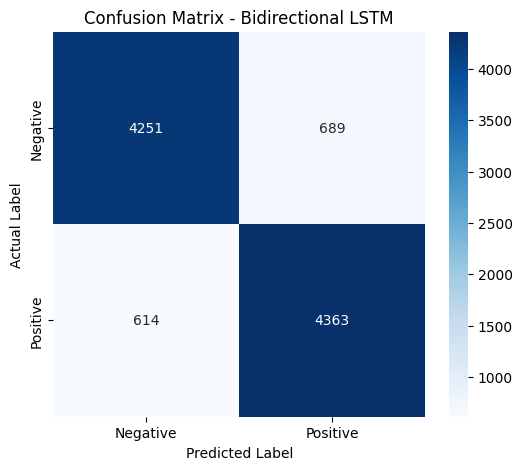

In [ ]:
# ============================================================
# Confusion Matrix of the Bidirectional LSTM Model
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.title("Confusion Matrix - Bidirectional LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The confusion matrix indicates that the Bidirectional LSTM model classified both positive and negative movie reviews effectively. The model correctly identified **4251 negative reviews (True Negatives)** and **4363 positive reviews (True Positives)**. It incorrectly classified **689 negative reviews as positive (False Positives)** and **614 positive reviews as negative (False Negatives)**. The relatively balanced distribution of misclassifications demonstrates that the model performs consistently across both sentiment classes without significant prediction bias.

# Section 24: Training and Validation Performance Curves
This section visualizes the learning behavior of the Bidirectional LSTM model during training. The training and validation accuracy curves illustrate how the model improved over successive epochs, while the training and validation loss curves help identify convergence and potential overfitting.

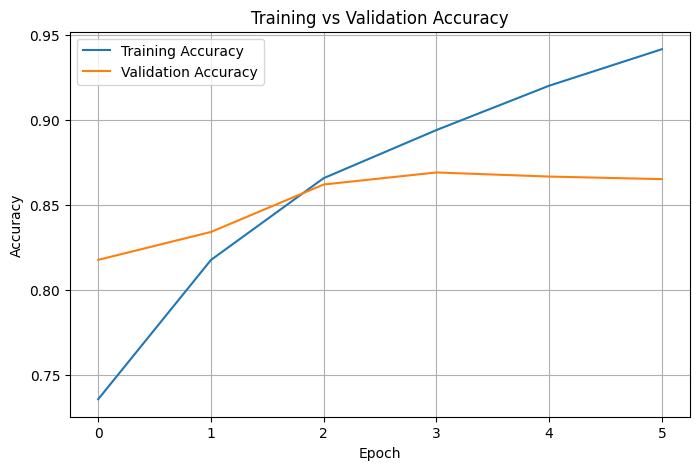

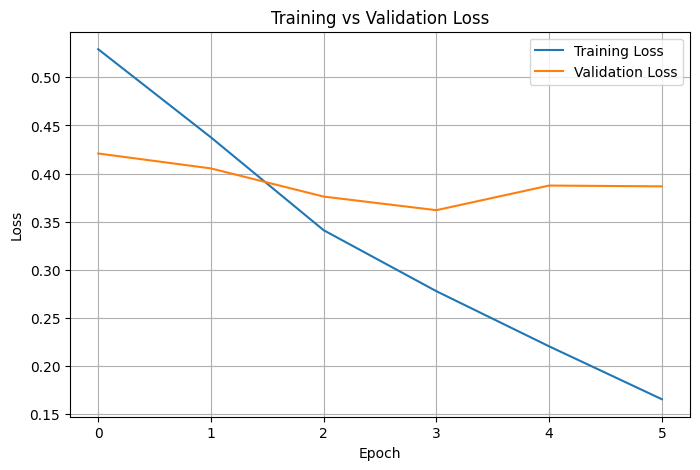

In [ ]:
# ============================================================
# Training and Validation Performance Curves
# ============================================================

import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


# Plot Training & Validation Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Observation

The training and validation curves demonstrate that the Bidirectional LSTM model learned the sentiment classification task effectively during the initial epochs. Training accuracy increased consistently while training loss decreased throughout the learning process. The validation accuracy improved up to **86.90%** at **Epoch 4**, after which it showed a slight decline, whereas the validation loss started increasing. This behavior indicates the beginning of overfitting after the fourth epoch. The EarlyStopping callback successfully restored the model weights from the best-performing epoch, ensuring improved generalization on unseen data.

# Section 25: Comparative Analysis of Machine Learning and Deep Learning Models
This section compares the performance of the three implemented sentiment classification models: Logistic Regression, Support Vector Machine (SVM), and Bidirectional LSTM. The comparison is based on four standard evaluation metrics: Accuracy, Precision, Recall, and F1-Score. This analysis helps identify the most effective model for the IMDb Movie Review sentiment classification task.

In [ ]:
# ============================================================
# Comparative Analysis of All Models
# ============================================================

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Bidirectional LSTM"
    ],
    "Accuracy": [
        0.8917,
        0.8821,
        0.8686
    ],
    "Precision": [
        0.8830,
        0.8797,
        0.8636
    ],
    "Recall": [
        0.9040,
        0.8863,
        0.8766
    ],
    "F1-Score": [
        0.8934,
        0.8830,
        0.8701
    ]
})

print("=" * 80)
print("Comparison of Machine Learning and Deep Learning Models")
print("=" * 80)

display(comparison_df)

Comparison of Machine Learning and Deep Learning Models


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8917,0.8830,0.9040,0.8934
1,Support Vector Machine,0.8821,0.8797,0.8863,0.8830
2,Bidirectional LSTM,0.8686,0.8636,0.8766,0.8701


### Observation

The comparative analysis indicates that **Logistic Regression** achieved the highest overall performance with an **accuracy of 89.17%**, followed by the **Support Vector Machine (SVM)** with **88.21%**, while the **Bidirectional LSTM** achieved **86.86%**. Logistic Regression also obtained the highest Precision, Recall, and F1-Score among all three models. Although the Bidirectional LSTM did not outperform the traditional machine learning models in terms of accuracy, it demonstrated strong performance by learning contextual representations directly from raw text sequences without relying on TF-IDF feature engineering. Overall, all three models achieved high classification performance, with Logistic Regression emerging as the most effective model for the IMDb sentiment analysis dataset used in this project.

# Section 26: Save the Trained Models
To enable future use without retraining, all trained machine learning and deep learning models are saved to disk. Saving the models allows them to be reloaded later for prediction, evaluation, or deployment.

In [ ]:
# ============================================================
# Save All Trained Models
# ============================================================

import joblib

# Save Machine Learning Models
joblib.dump(logistic_model, "logistic_regression_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")

# Save Deep Learning Model
best_model.save("bidirectional_lstm_model.keras")

print("=" * 60)
print("All Models Saved Successfully!")
print("=" * 60)

print("1. logistic_regression_model.pkl")
print("2. svm_model.pkl")
print("3. bidirectional_lstm_model.keras")

All Models Saved Successfully!
1. logistic_regression_model.pkl
2. svm_model.pkl
3. bidirectional_lstm_model.keras


### Observation

All trained models were successfully saved in their respective formats. The Logistic Regression and Support Vector Machine models were stored as **.pkl** files using the Joblib library, while the Bidirectional LSTM model was saved in the **.keras** format. These saved models can be loaded in future sessions for prediction, evaluation, or deployment without requiring retraining.

# Section 27: Conclusion
This section summarizes the overall findings of the sentiment analysis project by comparing the performance of traditional machine learning models and a deep learning model on the IMDb Movie Reviews dataset.

## Conclusion

In this project, sentiment analysis was performed on the IMDb Movie Reviews dataset using both traditional machine learning algorithms and a deep learning approach. The dataset was preprocessed through text cleaning, duplicate removal, tokenization, TF-IDF vectorization, and sequence padding, depending on the requirements of each model.

Three different models were implemented and evaluated: Logistic Regression, Support Vector Machine (SVM), and Bidirectional LSTM. Their performance was assessed using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

Among the evaluated models, **Logistic Regression achieved the highest performance with an accuracy of 89.17%**, followed by **Support Vector Machine with 88.21%**, while the **Bidirectional LSTM achieved 86.86%**. Although the Bidirectional LSTM did not surpass the traditional machine learning models in this experiment, it effectively learned contextual information directly from sequential text data without relying on handcrafted TF-IDF features.

Overall, the project demonstrates that both traditional machine learning and deep learning techniques can effectively perform sentiment analysis. The choice of model depends on factors such as dataset characteristics, computational resources, and application requirements. This project also highlights the importance of proper data preprocessing, model evaluation, and performance comparison when developing sentiment analysis systems.